In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import random

from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
STATE_SCALE = 10

In [3]:
# observations = []
# actions  = []

# # ['smm', 'icm', 'icm_apt', 'disagreement', 'proto', 'diayn', 'aps', 'rnd']
# for ualgo in ['icm_apt']:
#     npz_files = os.listdir(f'datasets/point_mass_maze/{ualgo}/buffer/')
#     for file_name in tqdm(npz_files, desc=ualgo):
#         data = np.load(f'datasets/point_mass_maze/{ualgo}/buffer/{file_name}')
#         observations.append(data['observation'])
#         actions.append(data['action'])
    
# observations = torch.tensor(np.concatenate(observations))
# actions = torch.tensor(np.concatenate(actions))

## FRE:

In [4]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 100),
            nn.LayerNorm(100),
            nn.Mish(),
            # nn.Linear(100, 100),
            # nn.LayerNorm(100),
            # nn.Mish(),
            # nn.Linear(100, 100),
            # nn.LayerNorm(100),
            # nn.Mish(),
            nn.Linear(100, 1),
        )



    def get_transformer_encoding(self, states, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        state_emb = self.state_embed(states)        

        w_pre = self.encoder_transformer(state_emb, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [5]:
def get_training_data(batch_size, min_num_anchors, max_num_anchors, num_states):
    assert min_num_anchors <= max_num_anchors <= num_states
    # anchors_idx = torch.randint(0, observations.shape[0], (batch_size, num_anchors,))
    # other_idx = torch.randint(0, observations.shape[0], (batch_size, num_states - num_anchors,))
    # anchors = observations[anchors_idx]
    # non_anchors = observations[other_idx]
    
    anchors = torch.rand((batch_size, max_num_anchors, 2)) * 0.6 - 0.3
    non_anchors = torch.rand((batch_size, num_states - max_num_anchors, 2)) * 0.6 - 0.3
    
    anchors = anchors * STATE_SCALE
    non_anchors = non_anchors * STATE_SCALE
    
    
    # print(anchors.shape, non_anchors.shape)

    all_states = torch.concatenate((anchors, non_anchors), dim=1)
    all_states.shape

    rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float32)
    rewards[:, :max_num_anchors] = 1
    rewards[:, max_num_anchors:] = 0
    
    pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
    for i in range(batch_size):
        num_anchors = random.randint(min_num_anchors, max_num_anchors)
        anchors   [i, num_anchors:max_num_anchors] = 0
        all_states[i, num_anchors:max_num_anchors] = 0
        rewards   [i, num_anchors:max_num_anchors] = 0
        pad_mask  [i, :num_anchors] = False
        

    return (anchors, pad_mask), (all_states, rewards)


(anchors, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=256, 
    min_num_anchors=4,
    max_num_anchors=7,
    num_states=128)

In [6]:
# anchors.shape, pad_mask.shape

# embeddings = anchors
# padding_mask = pad_mask

# # Convert padding mask to a float tensor for computation
# valid_tokens = (~padding_mask).float()  # (B, T), converts True -> 0, False -> 1
# valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
# sum_embeddings = (embeddings * valid_tokens).sum(dim=1)  # Sum over sequence dimension
# mean_embeddings = sum_embeddings / valid_tokens.sum(dim=1)

In [9]:
fre_network = FRENetwork(obs_len=2).to(device)
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

steps = 100000

losses = []
pred_losses = []

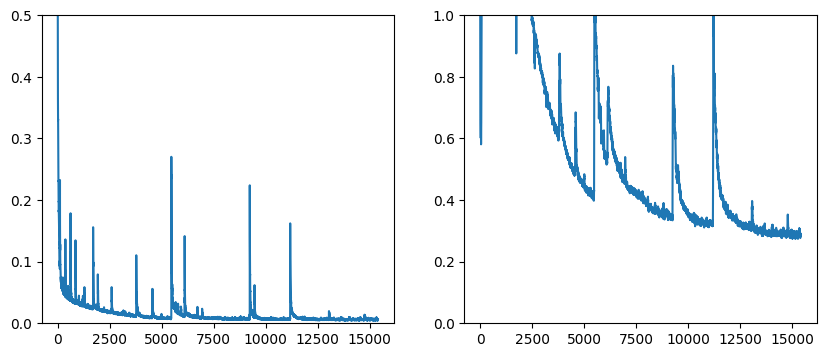

 15%|█▌        | 15460/100000 [02:12<12:04, 116.61it/s]


KeyboardInterrupt: 

In [10]:
min_num_anchors = 1
max_num_anchors = 1

for i in tqdm(range(steps)):
    
    (anchors, pad_mask), (all_states, rewards) = get_training_data(
        batch_size=256, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=16
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)
    all_states = all_states.to(device)
    rewards = rewards.to(device)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, pad_mask=pad_mask)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, all_states)
    # rewards_pred = torch.clip(rewards_pred, 0, 1)
    
    is_anchor = (rewards == 1)
    reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + \
                       ((rewards_pred[~is_anchor] - 0)**2).mean() * 0.5
                       
    
    kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
    reward_kl_loss = reward_pred_loss + kl_loss * 0.01
    loss = reward_kl_loss
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    losses.append(loss.item())
    pred_losses.append(kl_loss.item())
    
    # break
    if i % 200 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
        axs[0].plot(losses)
        axs[0].set_ylim([0, 0.5])
        
        axs[1].plot(pred_losses)
        axs[1].set_ylim([0, 1])
        
    
        plt.show()
        
        

In [11]:
# torch.save(fre_network.state_dict(), 'models/reward_generator.pth')
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

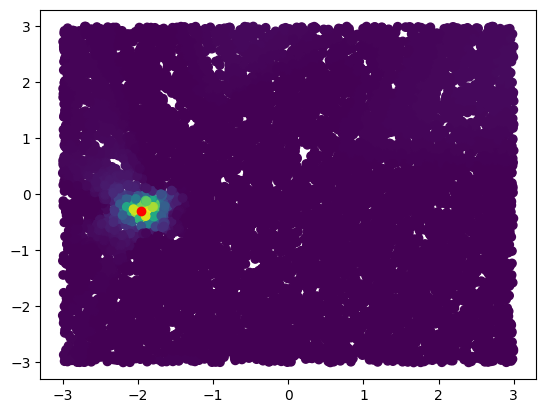

In [16]:
num_anchors = 1
min_num_anchors, max_num_anchors = num_anchors, num_anchors
(anchors, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
anchors = anchors.to(device)
# anchors = torch.zeros_like(anchors).to(device)
all_states = all_states.to(device)
rewards = rewards.to(device)


w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, None)   

# Calculate the loss:

w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
# w = torch.normal(0, 1, (1, 128), device=device) * 0.5

rewards_pred = fre_network.get_reward_pred(w, all_states)

# reward_pred_loss = ((rewards_pred - rewards)**2).mean()
# kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
# reward_kl_loss = reward_pred_loss + kl_loss * 0.01
# loss = reward_kl_loss


plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red')

100%|██████████| 1000/1000 [00:01<00:00, 933.46it/s]


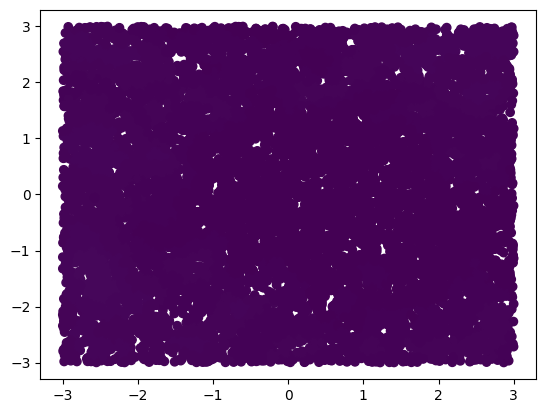

In [17]:
num_anchors = 1
min_num_anchors, max_num_anchors = num_anchors, num_anchors
# min_num_anchors, max_num_anchors = 1, 8

(_, _), (all_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
all_states = all_states.to(device)


r = []
for _  in tqdm(range(1000)):
    
    (anchors, _), (_, _) = get_training_data(
        batch_size=1, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=10000
    )
    
    anchors = anchors.to(device)

    with torch.no_grad():
        w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, None)   
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        rewards_pred = fre_network.get_reward_pred(w, all_states)
    
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)

# Sample from prior without anchors:

In [21]:
all_means, all_vars = [], []

for  _ in tqdm(range(10000)):
    min_num_anchors = 1
    max_num_anchors = 1
    (anchors, _), (_, _) = get_training_data(
        batch_size=1, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=10
    )
    anchors = anchors.to(device)

    with torch.no_grad():
        w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, None)   
        var = torch.exp(2*w_log_std)
    all_means.append(w_mean[0].cpu())
    all_vars.append(var[0].cpu())

emperical_mean = torch.stack(all_means).mean(dim=0).to(device)
# emperical_std = torch.stack(all_stds).mean(dim=0).to(device)

sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
emperical_std = sigma_hat ** 0.5

100%|██████████| 10000/10000 [00:06<00:00, 1504.64it/s]


In [22]:
# torch.save({'emperical_mean':emperical_mean, 'emperical_std':emperical_std}, 'models/reward_generator_mean_std.pth')

100%|██████████| 1000/1000 [00:00<00:00, 3730.86it/s]


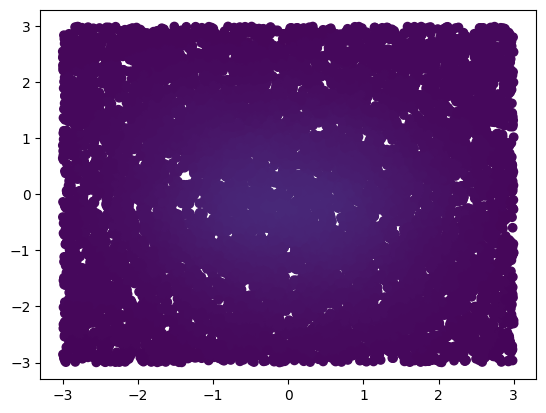

In [23]:
(_, _), (all_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=1, 
    max_num_anchors=1,
    num_states=10000
)
all_states = all_states.to(device)


r = []
for _ in tqdm(range(1000)):
    w = emperical_mean  + torch.normal(0, 1, emperical_mean.shape, device=device) * emperical_std
    # w = torch.normal(0, 1, emperical_mean.shape, device=device)
    
    w = w.unsqueeze(0)

    with torch.no_grad():
        rewards_pred = fre_network.get_reward_pred(w, all_states)
        
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)

In [ ]:
# _ = plt.hist(torch.stack(r[:100]).flatten(), bins=100)  

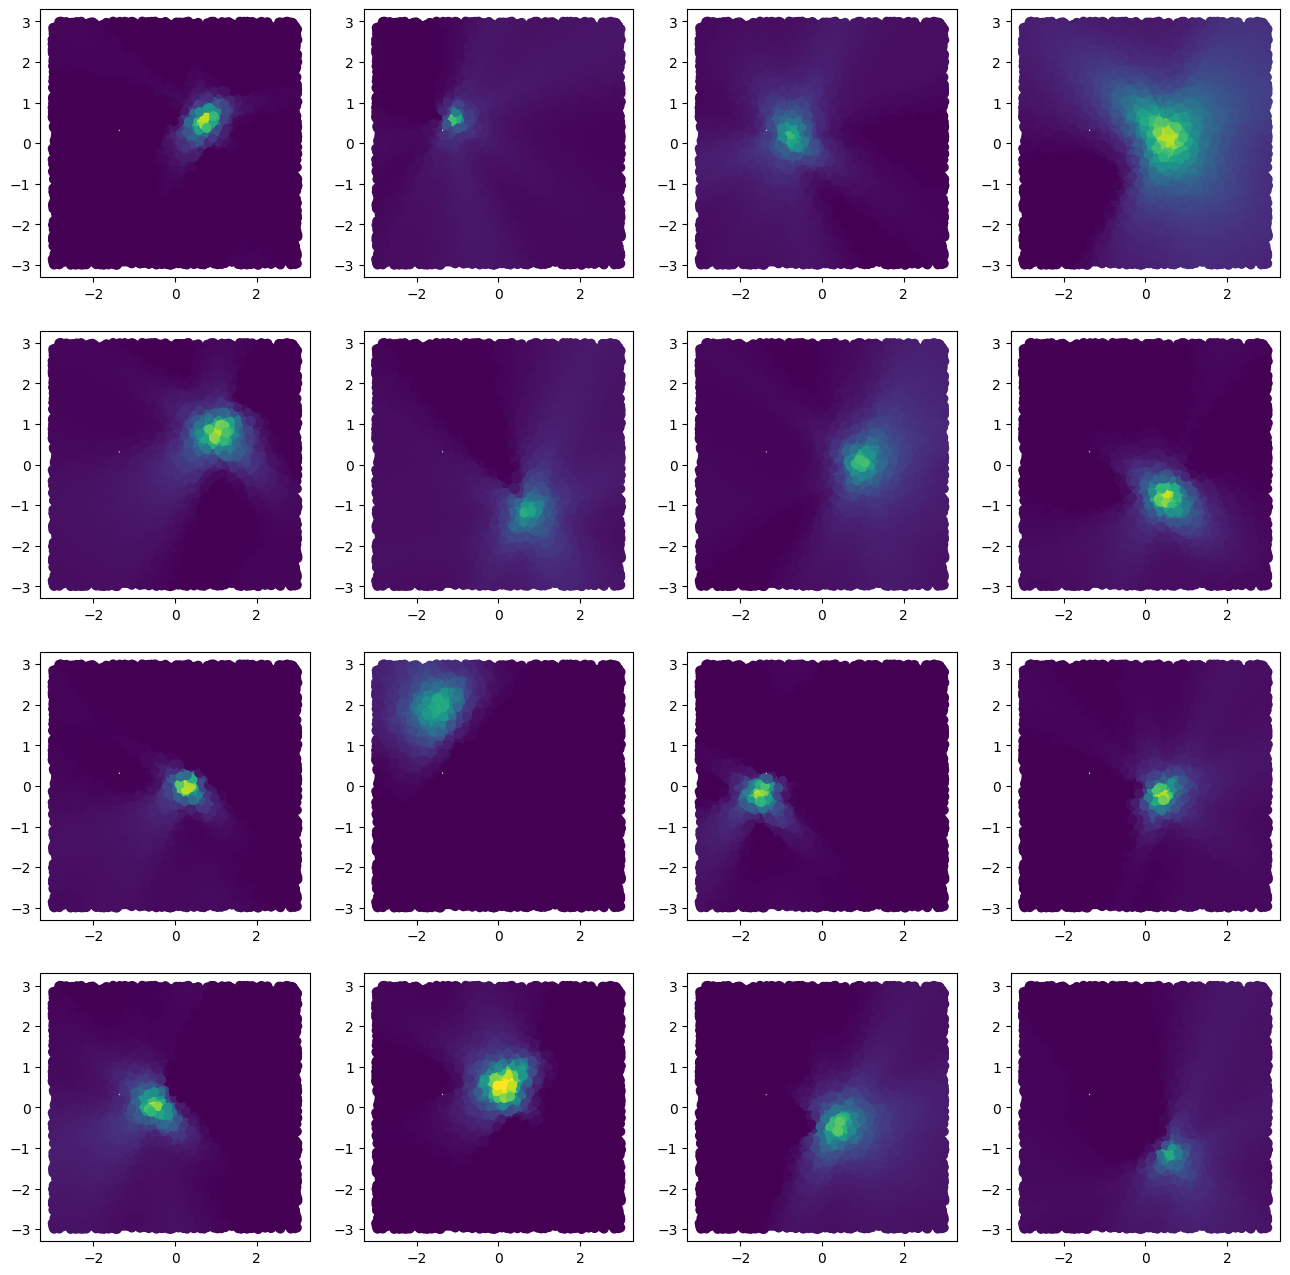

In [24]:
N = 4
fig, axs = plt.subplots(N, N, figsize=(4*N, 4*N))
axs = axs.flatten()
for i in range(N*N):
    axs[i].scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=r[i].detach().cpu(), vmin=0, vmax=1)

# Find z from zero shot:

In [ ]:
(_, _), (all_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=1, 
    max_num_anchors=1,
    num_states=10000
)

(_, _), (test_states, _) = get_training_data(
    batch_size=1, 
    min_num_anchors=1, 
    max_num_anchors=1,
    num_states=32
)

all_states, test_states = all_states.to(device), test_states.to(device)

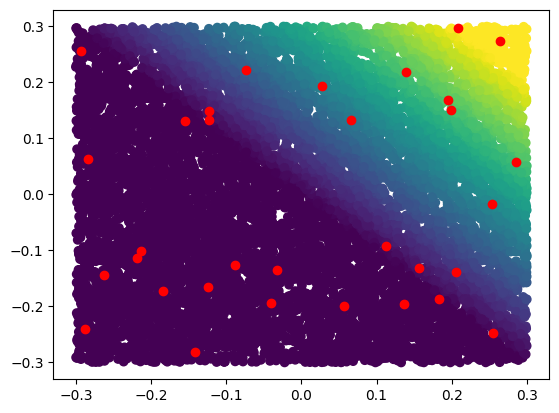

In [ ]:
eval_direction_t  = lambda obs: (obs[:, :].sum(axis=-1)) * 2
r = eval_direction_t(all_states)
r = torch.clip(r, 0, 1)

plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=r.detach().cpu(), vmin=0, vmax=1)
plt.scatter(test_states[0, :, 0].cpu(), test_states[0, :, 1].cpu(), c='red')

test_r = eval_direction_t(test_states)

In [ ]:
def log_likelihood(x, mu, v):
    return torch.sum(-0.5 * torch.log(2 * torch.pi * v**2) - ((x - mu) ** 2) / (2 * v**2))


dist_losses = []
log_losses = []

test_w = emperical_mean  + torch.normal(0, 1, emperical_mean.shape, device=device) * emperical_std
test_w = test_w.unsqueeze(0)
test_w = nn.Parameter(test_w)

optim = torch.optim.Adam([test_w], lr=0.01)

for i in tqdm(range(10000)):

    rewards_pred = fre_network.get_reward_pred(test_w, test_states).flatten()    
    dist_loss = ((rewards_pred - test_r)**2).mean()
    log_likelihood_loss = log_likelihood(test_w.reshape(-1), emperical_mean, emperical_std)
    
    
    loss = dist_loss - 0.001*log_likelihood_loss
    optim.zero_grad()
    loss.backward()
    optim.step()    
    
    dist_losses.append(dist_loss.item())
    log_losses.append(log_likelihood_loss.item())
    
    if i % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(dist_losses)
        axs[1].plot(log_losses)
        plt.show()
    
    
    # break

 28%|██▊       | 2760/10000 [00:36<01:35, 75.52it/s]


KeyboardInterrupt: 

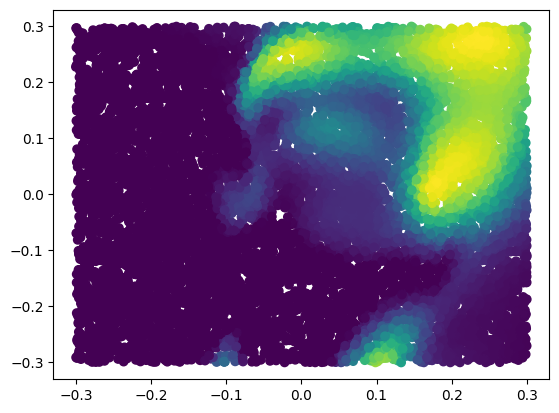

In [ ]:
rewards_pred = fre_network.get_reward_pred(test_w.data, all_states)

plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)

In [ ]:
def log_likelihood(x, mu, v):
    print((torch.log(2 * torch.pi * v**2)).shape)
    return torch.sum(-0.5 * torch.log(2 * torch.pi * v**2) - ((x - mu) ** 2) / (2 * v**2))

# Example usage
x = test_w.data.reshape(-1)
# x = emperical_mean  + torch.normal(0, 1, emperical_mean.shape, device=device) * emperical_std
# x = torch.normal(0, 1, emperical_mean.shape, device=device)

mu = emperical_mean.reshape(-1)
v = emperical_std.reshape(-1)

# mu, v = torch.zeros_like(emperical_mean), torch.ones_like(emperical_mean)

log_likelihood_value = log_likelihood(x, mu, v)
torch.exp(log_likelihood_value/128)
# log_likelihood_value

torch.Size([128])


tensor(0.3555, device='cuda:0')